# MITGCM - Data Visualization

**Purpose**: Code for visualizing MITgcm potential density and along/cross shore data

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [3]:
%matplotlib inline

Import python libraries

In [4]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import matplotlib.colors as mcolors

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize
from spectra import spectrum1D_frequency, spectral_slope
from lsf import unweighted_lsf, detrend
from structure_functions import compute_structure_function
from var_analysis import variance_scale_analysis_1D

In [5]:
def add_corner_label(ax, pos, label, fontsize=12):
    
    # Place text in lower left corner inside the axes
    ax.text(
        pos[0], pos[1], label,
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight='normal',
        va='top', ha='left',
        bbox=dict(
            boxstyle='square,pad=0.3',
            facecolor=(1, 1, 1, 0.6),  # faded white fill with alpha=0.6
            edgecolor='black',
            linewidth=1
        )
    )

def month_fmt(x, pos):
    dt = mdates.num2date(x)
    if dt.month == 1:
        return f"J\n{dt.year}"  # January tick with year underneath
    else:
        return dt.strftime('%b')[0]  # Just the first letter

Set data analysis parameters

In [6]:
# Set processing parameters
option_plot          = 0      # Specifies if supplementary plots are plotted
option_var           = 'density'  # Specifies which variable will analyzed. Options include: temp, sal, density, u_along, v_cross
option_bin           = 0

# Set time and space parameters
T            = 1*(60)*(60)                   # Spcifies the time interval for model run. Units: seconds
estimator    = 'biased'                      # Specifies the approach for estimating the autocorrelation function    
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs_server/mitgcm/scale_analysis/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 16

Load mitgcm data netcdf files 

In [7]:
#--- MITgcm Data ---# 
filename_tsd = PATH + "mitgcm_intermediate_data_TSD_hrly_ts_profiles.nc"
filename_vel = PATH + "mitgcm_intermediate_data_vel_hrly_ts_profiles.nc"
nc_tsd = Dataset(filename_tsd, 'r')
nc_vel = Dataset(filename_vel, 'r')

# Extract data variables
depth = nc_tsd.variables['depth'][:]
lon   = nc_tsd.variables['LON'][:]
lat   = nc_tsd.variables['LAT'][:]
time  =  num2date(nc_tsd.variables['time'][:], nc_tsd.variables['time'].units)

sig     = nc_tsd.variables['SIG'][:]
u_along = nc_vel.variables['u_along'][:]
v_cross = nc_vel.variables['v_cross'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Set plotting parameters

In [8]:
# Set font and fontsize 
fontsize = 16
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

# Set contour levels
level_sig = np.linspace(23,27,20)
level_vel = np.linspace(-0.8,0.8,20)

# Create a normalization object
norm_sig = mcolors.Normalize(vmin=23, vmax=27)
norm_vel = mcolors.Normalize(vmin=-0.8, vmax=0.8) #mcolors.TwoSlopeNorm(vmin=-0.8, vcenter=0, vmax=0.8)

Plot the potential density, along-shelf velocity, and cross-shelf velocity profile time series

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_10209/2186537326.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


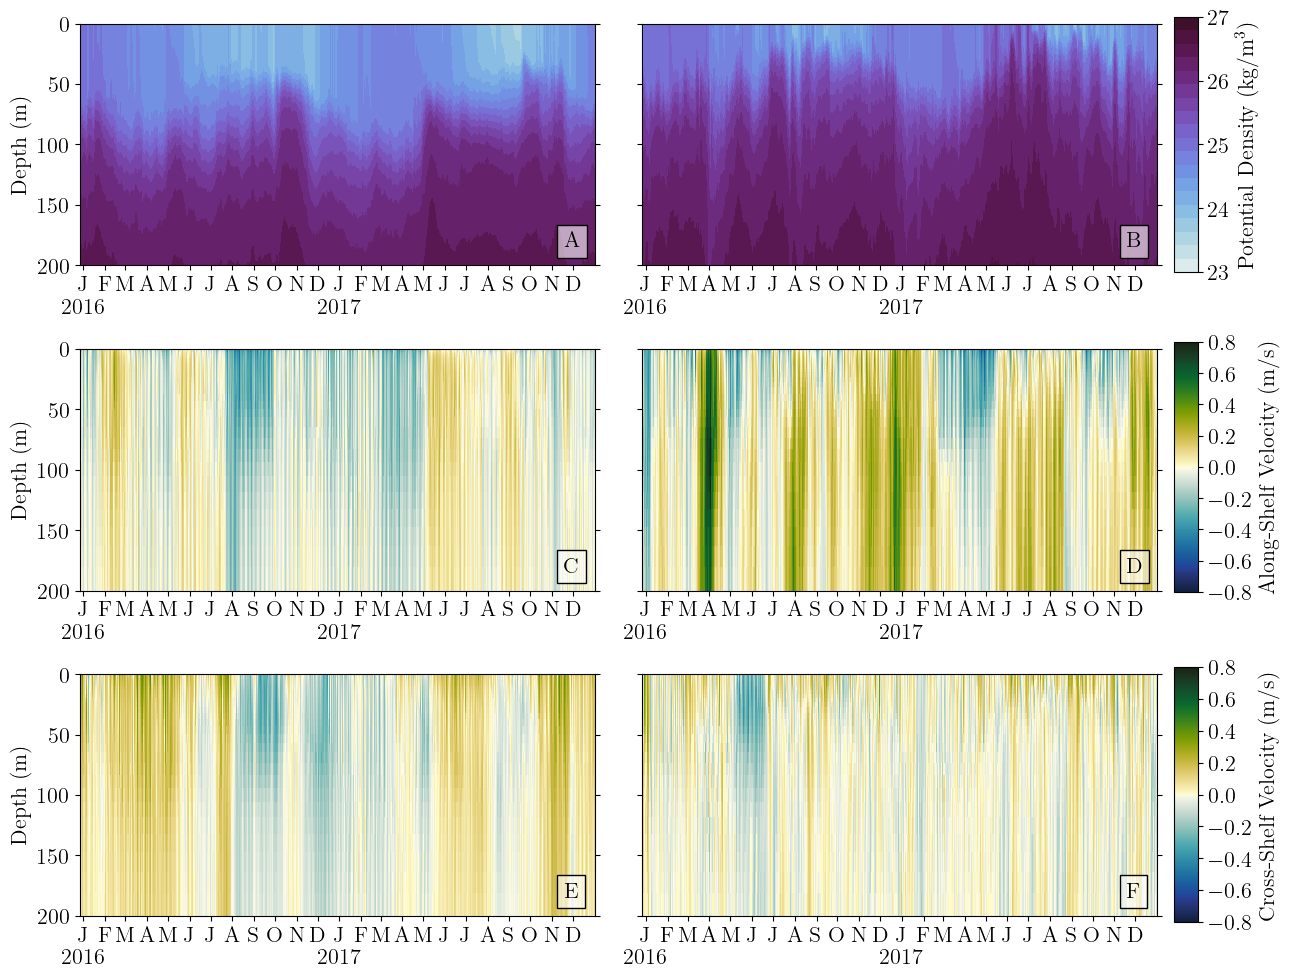

In [ ]:
# Create figure
fig,axes = plt.subplots(3,2,figsize=(12, 10))
ax1,ax2,ax3,ax4,ax5,ax6 =  axes.flatten()

#--- Subplot 1 ---# 

# Plot CCE1 potential density
cf = ax1.contourf(time_dt,abs(depth),sig[0,:,:].T, levels = level_sig, cmap=cmo.dense,norm=norm_sig)

# Set axis attributes
ax1.set_ylabel("Depth (m)")
ax1.set_ylim(0,200)
ax1.invert_yaxis()
ax1.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(FuncFormatter(month_fmt))

#--- Subplot 2 ---# 

# Plot CCE2 potential density
ax2.contourf(time_dt,abs(depth),sig[1,:,:].T, levels = level_sig, cmap=cmo.dense,norm=norm_sig)

# Set axis attributes
ax2.set_ylim(0,200)
ax2.invert_yaxis()
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax2.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax2.set_yticklabels([])

# Set colorbar
cax = fig.add_axes([0.99, 0.72, 0.02, 0.255])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical')
cbar.set_ticks([23, 24, 25, 26, 27])   # positions
cbar.set_label(r'Potential Density (kg/m$^3$)')

#--- Subplot 3 ---# 

# Plot CCE1 along-shelf velocity
cf = ax3.pcolormesh(time_dt,abs(depth),u_along[0,:,:].T,  cmap=cmo.delta, vmin=-0.8,vmax=0.8)

# Set axis attributes
ax3.set_ylabel("Depth (m)")
ax3.set_ylim(0,200)
ax3.invert_yaxis()
ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax3.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)

#--- Subplot 4 ---# 

# Plot CCE2 along-shelf velocity
ax4.pcolormesh(time_dt,abs(depth),u_along[1,:,:].T, cmap=cmo.delta, vmin=-0.8,vmax=0.8)

# Set axis attributes
ax4.set_ylim(0,200)
ax4.invert_yaxis()
ax4.xaxis.set_major_locator(mdates.MonthLocator())
ax4.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax4.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax4.set_yticklabels([])

# Set colorbar
cax = fig.add_axes([0.99, 0.40, 0.02, 0.25])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical')
cbar.ax.set_ylim(-0.8,0.8)
cbar.set_ticks(np.arange(-0.8,0.8+0.2,0.2))   # positions
cbar.set_label(r'Along-Shelf Velocity (m/s)')

#--- Subplot 5 ---# 

# Plot CCE1 cross-shelf velocity
cf = ax5.pcolormesh(time_dt,abs(depth),v_cross[0,:,:].T, cmap=cmo.delta, vmin=-0.8,vmax=0.8)

# Set axis attributes
ax5.set_ylabel("Depth (m)")
ax5.set_ylim(0,200)
ax5.invert_yaxis()
ax5.xaxis.set_major_locator(mdates.MonthLocator())
ax5.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax5.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)

#--- Subplot 6 ---# 

# Plot CCE2 cross-shelf velocity
ax6.pcolormesh(time_dt,abs(depth),v_cross[1,:,:].T, cmap=cmo.delta, vmin=-0.8,vmax=0.8)

# Set axis attributes
ax6.set_ylim(0,200)
ax6.invert_yaxis()
ax6.xaxis.set_major_locator(mdates.MonthLocator())
ax6.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax6.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax6.set_yticklabels([])

# Set colorbar
cax = fig.add_axes([0.99, 0.07, 0.02, 0.255])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical')
cbar.ax.set_ylim(-0.8,0.8)
cbar.set_ticks(np.arange(-0.8,0.8+0.2,0.2))
cbar.set_label(r'Cross-Shelf Velocity (m/s)')

# Label each subplot
pos = [0.94, 0.14]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)
add_corner_label(ax5, pos, 'E', fontsize = fontsize)
add_corner_label(ax6, pos, 'F', fontsize = fontsize)

# Show figure
plt.tight_layout()
plt.show()

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_10209/3739993647.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


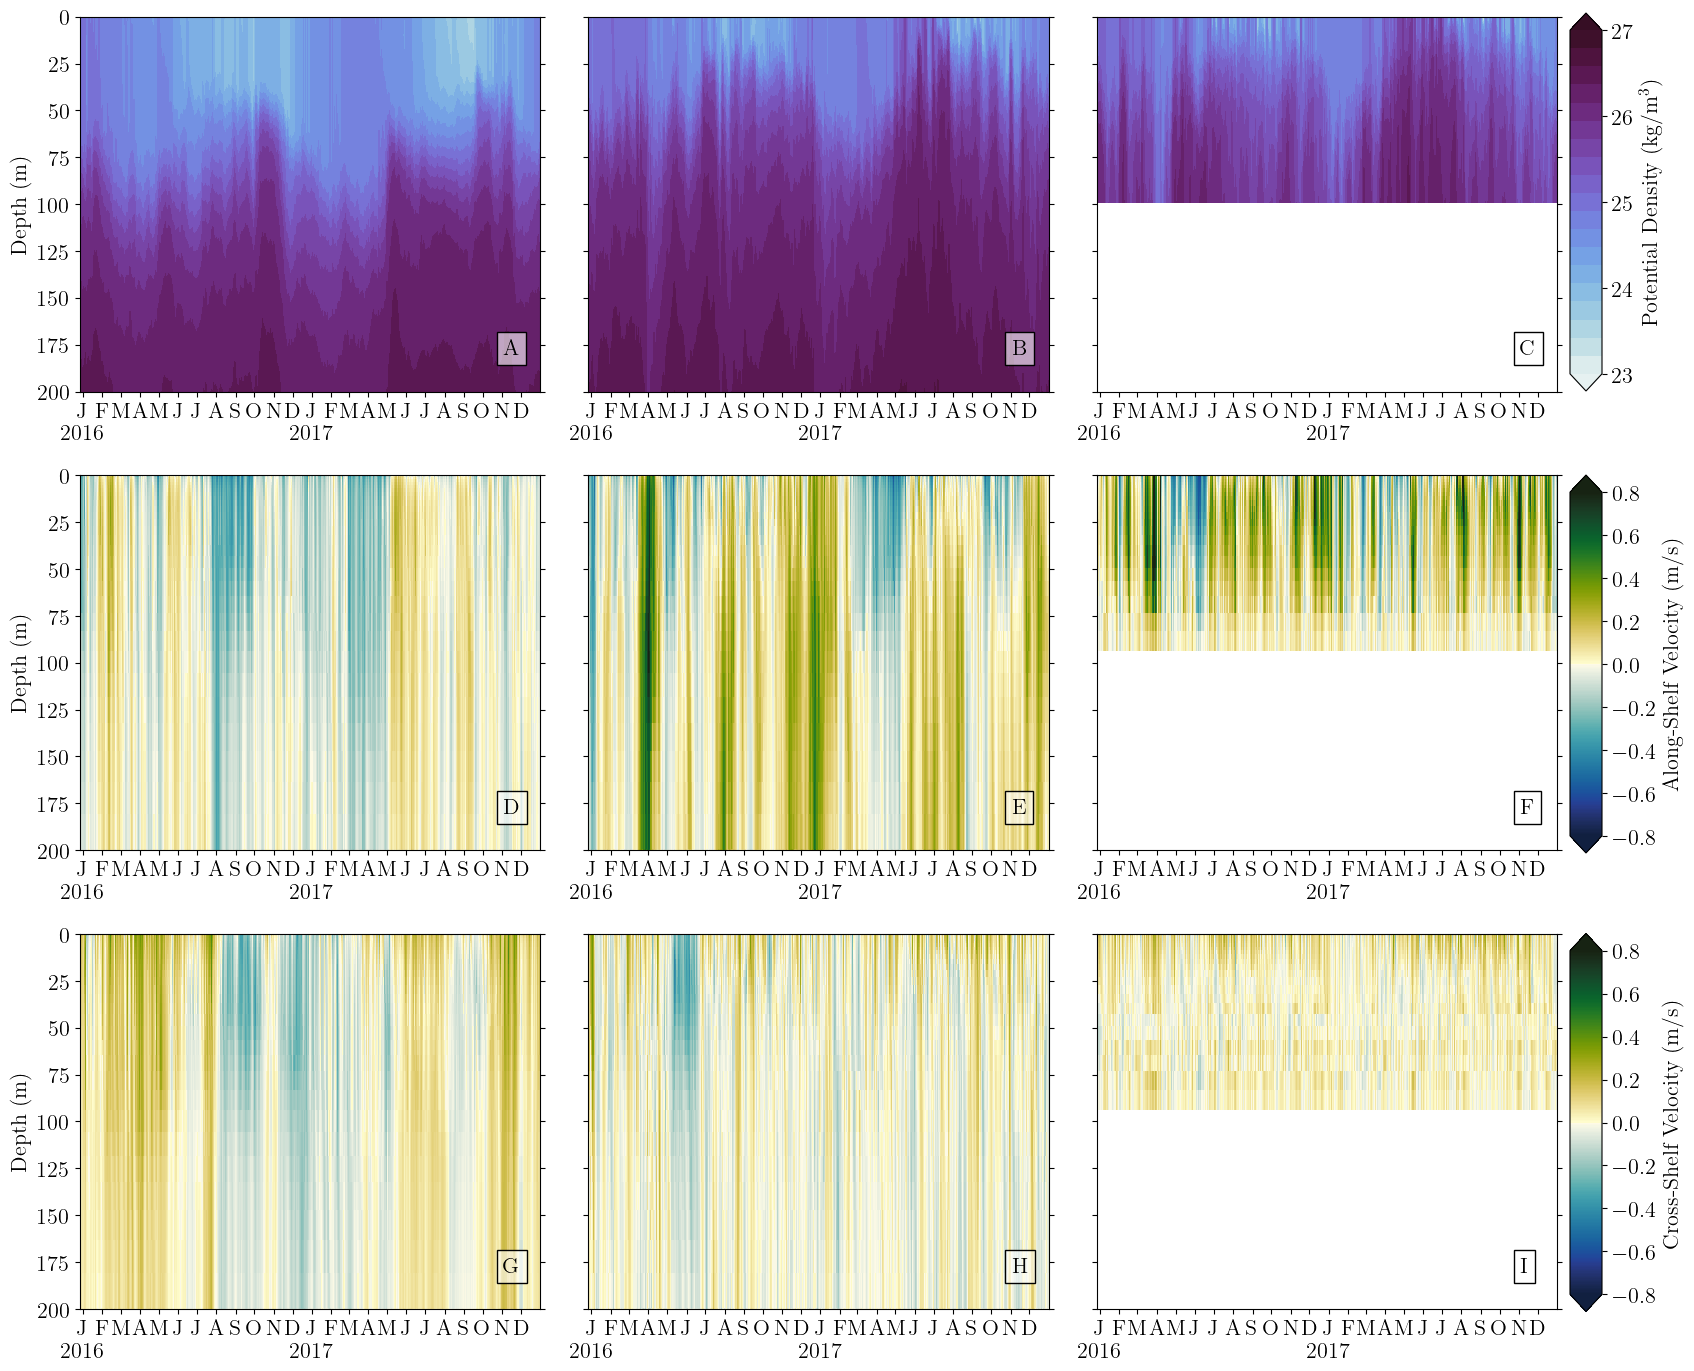

In [19]:
# Create figure
fig,axes = plt.subplots(3,3,figsize=(16, 14))
ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9 =  axes.flatten()

#--- Subplot 1 ---# 

# Plot CCE1 potential density
cf = ax1.contourf(time_dt,abs(depth),sig[0,:,:].T, levels = level_sig, cmap=cmo.dense,norm=norm_sig,extend='both')

# Set axis attributes
ax1.set_ylabel("Depth (m)")
ax1.set_ylim(0,200)
ax1.invert_yaxis()
ax1.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(FuncFormatter(month_fmt))

#--- Subplot 2 ---# 

# Plot CCE2 potential density
ax2.contourf(time_dt,abs(depth),sig[1,:,:].T, levels = level_sig, cmap=cmo.dense,norm=norm_sig,extend='both')

# Set axis attributes
ax2.set_ylim(0,200)
ax2.invert_yaxis()
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax2.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax2.set_yticklabels([])


#--- Subplot 3 ---# 

# Plot CCE2 potential density
ax3.contourf(time_dt,abs(depth),sig[2,:,:].T, levels = level_sig, cmap=cmo.dense,norm=norm_sig,extend='both')

# Set axis attributes
ax3.set_ylim(0,200)
ax3.invert_yaxis()
ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax3.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax3.set_yticklabels([])

# Set colorbar
cax = fig.add_axes([0.99, 0.71, 0.02, 0.27])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical',extend='both')
cbar.set_ticks([23, 24, 25, 26, 27])   # positions
cbar.set_label(r'Potential Density (kg/m$^3$)')

#--- Subplot 4 ---# 

# Plot CCE1 along-shelf velocity
cf = ax4.pcolormesh(time_dt,abs(depth),u_along[0,:,:].T,  cmap=cmo.delta, vmin=-0.8,vmax=0.8)

# Set axis attributes
ax4.set_ylabel("Depth (m)")
ax4.set_ylim(0,200)
ax4.invert_yaxis()
ax4.xaxis.set_major_locator(mdates.MonthLocator())
ax4.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax4.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)

#--- Subplot 5 ---# 

# Plot CCE2 along-shelf velocity
ax5.pcolormesh(time_dt,abs(depth),u_along[1,:,:].T, cmap=cmo.delta, vmin=-0.8,vmax=0.8)

# Set axis attributes
ax5.set_ylim(0,200)
ax5.invert_yaxis()
ax5.xaxis.set_major_locator(mdates.MonthLocator())
ax5.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax5.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax5.set_yticklabels([])

#--- Subplot 6 ---# 

# Plot CCE2 along-shelf velocity
ax6.pcolormesh(time_dt,abs(depth),u_along[2,:,:].T, cmap=cmo.delta, vmin=-0.8,vmax=0.8)

# Set axis attributes
ax6.set_ylim(0,200)
ax6.invert_yaxis()
ax6.xaxis.set_major_locator(mdates.MonthLocator())
ax6.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax6.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax6.set_yticklabels([])

# Set colorbar
cax = fig.add_axes([0.99, 0.38, 0.02, 0.27])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical',extend='both')
cbar.ax.set_ylim(-0.8,0.8)
cbar.set_ticks(np.arange(-0.8,0.8+0.2,0.2))   # positions
cbar.set_label(r'Along-Shelf Velocity (m/s)')

#--- Subplot 7 ---# 

# Plot CCE1 cross-shelf velocity
cf = ax7.pcolormesh(time_dt,abs(depth),v_cross[0,:,:].T, cmap=cmo.delta, vmin=-0.8,vmax=0.8)

# Set axis attributes
ax7.set_ylabel("Depth (m)")
ax7.set_ylim(0,200)
ax7.invert_yaxis()
ax7.xaxis.set_major_locator(mdates.MonthLocator())
ax7.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax7.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)

#--- Subplot 8 ---# 

# Plot CCE2 cross-shelf velocity
ax8.pcolormesh(time_dt,abs(depth),v_cross[1,:,:].T, cmap=cmo.delta, vmin=-0.8,vmax=0.8)

# Set axis attributes
ax8.set_ylim(0,200)
ax8.invert_yaxis()
ax8.xaxis.set_major_locator(mdates.MonthLocator())
ax8.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax8.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax8.set_yticklabels([])

#--- Subplot 9 ---# 

# Plot CCE2 cross-shelf velocity
ax9.pcolormesh(time_dt,abs(depth),v_cross[2,:,:].T, cmap=cmo.delta, vmin=-0.8,vmax=0.8)

# Set axis attributes
ax9.set_ylim(0,200)
ax9.invert_yaxis()
ax9.xaxis.set_major_locator(mdates.MonthLocator())
ax9.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax9.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax9.set_yticklabels([])

# Set colorbar
cax = fig.add_axes([0.99, 0.0525, 0.02, 0.27])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical',extend='both')
cbar.ax.set_ylim(-0.8,0.8)
cbar.set_ticks(np.arange(-0.8,0.8+0.2,0.2))
cbar.set_label(r'Cross-Shelf Velocity (m/s)')

# Label each subplot
pos = [0.92, 0.14]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)
add_corner_label(ax5, pos, 'E', fontsize = fontsize)
add_corner_label(ax6, pos, 'F', fontsize = fontsize)
add_corner_label(ax7, pos, 'G', fontsize = fontsize)
add_corner_label(ax8, pos, 'H', fontsize = fontsize)
add_corner_label(ax9, pos, 'I', fontsize = fontsize)

# Show figure
plt.tight_layout()
plt.show()